In [1]:
import glob

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.stats import genextreme as gev
from scipy import stats
import xclim as xc
from xclim import sdba
from xclim.sdba import nbutils

from unseen import fileio
from unseen import eva
from unseen import bias_correction
from unseen import time_utils
from unseen import stability

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/xclim/sdba/__init__.py:22: FutureWarning: The SDBA submodule is in the process of being split from `xclim` in order to facilitate development and effective maintenance of the SDBA utilities. The `xclim.sdba` functionality will change in the future. For more information, please visit https://xsdba.readthedocs.io/en/latest/.
  warnings.warn(


In [2]:
lat = {}
lon = {}

lat['Katherine'] = -14.5
lon['Katherine'] = 132.3

lat['Surat'] = -27.2
lon['Surat'] = 149.1

lat['Miena'] = -42.0
lon['Miena'] = 146.7

## Observations

In [3]:
def get_obs_data(metric, location):
    """Get obs data"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    
    obs_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/{metric}_AGCD-CSIRO_*_AUS300i.nc')[0]
    ds_obs = fileio.open_dataset(obs_file)
    da_obs = ds_obs[var[metric]].sel({'lat': lat[location], 'lon': lon[location]}, method='nearest')
    da_obs = da_obs.compute()

    return da_obs


def detrend_obs(da_obs):
    """Linearly detrend obs data."""

    linear_fit_obs = np.polyfit(da_obs.time.dt.year.values, da_obs.values, 1)
    linear_data_obs = np.polyval(linear_fit_obs, da_obs.time.dt.year.values)
    base_mean_obs = da_obs.sel(time=slice('1972-01-01', '2018-12-31')).mean().values
    da_obs_detrended = (da_obs - linear_data_obs) + base_mean_obs
    da_obs_detrended.attrs = da_obs.attrs

    return da_obs_detrended

## Model data

In [4]:
def get_model_data(metric, model, location):
    """Get grid point data for a single metric/model combination"""

    var = {'txx': 'tasmax', 'rx1day': 'pr'}
    model_file = glob.glob(f'/g/data/xv83/unseen-projects/outputs/bias/data/{metric}_{model}-*_*_annual-jul-to-jun_AUS300i.nc')[0]
    ds_model = fileio.open_dataset(model_file)
    da_model = ds_model[var[metric]].sel({'lat': lat[location], 'lon': lon[location]}, method='nearest')
    da_model = da_model.compute()
    da_model_stacked = da_model.dropna('lead_time').stack({'sample': ['ensemble', 'init_date', 'lead_time']})

    return da_model_stacked


def detrend_model(da_model_stacked):
    """linearly detrend model data."""

    linear_fit_model = np.polyfit(da_model_stacked.time.dt.year.values, da_model_stacked.values, 1)
    linear_data_model = np.polyval(linear_fit_model, np.unique(da_model_stacked.time.dt.year.values))
    da_model_stacked_base = time_utils.select_time_period(da_model_stacked.copy(), ['1972-01-01', '2018-12-31'])
    base_mean_model = da_model_stacked_base.mean().values
    value_year_pairs = np.column_stack((da_model_stacked.values, da_model_stacked.time.dt.year.values))
    detrended_data = []
    for value, year in value_year_pairs:
        af = np.polyval(linear_fit_model, year)
        detrended_value = value - af + base_mean_model
        detrended_data.append(detrended_value)
    detrended_data = np.array(detrended_data)
    da_model_detrended_stacked = da_model_stacked * 0 + detrended_data
    da_model_detrended_stacked.attrs = da_model_stacked.attrs

    return da_model_detrended_stacked

In [5]:
def mean_correction(da_model_detrended, da_obs_detrended, method):
    """Apply a mean correction."""

    assert method in ['additive', 'multiplicative']
    
    bias = bias_correction.get_bias(
        da_model_detrended,
        da_obs_detrended,
        method,
        time_rounding='A',
        time_period=['1972-01-01', '2018-12-31']
    )
    da_model_detrended_bc = bias_correction.remove_bias(da_model_detrended, bias, method)
    da_model_detrended_bc = da_model_detrended_bc.compute()
    da_model_detrended_bc_stacked = da_model_detrended_bc.dropna('lead_time').stack(
        {'sample': ['ensemble', 'init_date', 'lead_time']}
    )

    return da_model_detrended_bc_stacked

In [6]:
def get_smooth_adjustment_factor(value, data, af_cubic_fit):
    """Find the adjustment factor."""

    quantile = stats.percentileofscore(data, value) / 100
    af = np.polyval(af_cubic_fit, quantile)

    return af


vget_smooth_adjustment_factor = np.vectorize(get_smooth_adjustment_factor, excluded=['data', 'af_cubic_fit'])


def quantile_correction(da_model_detrended_stacked, da_obs_detrended, method):
    """Apply a mean correction."""

    assert method in ['additive', 'multiplicative']

    nquantiles = 10
    quantile_array = xc.sdba.utils.equally_spaced_nodes(nquantiles)
    da_model_detrended_q = nbutils.quantile(
        da_model_detrended_stacked,
        quantile_array,
        ['sample']
    )
    da_obs_detrended_q = nbutils.quantile(
        da_obs_detrended,
        quantile_array,
        ['time']
    )

    if method == 'additive':
        bias = da_model_detrended_q.values - da_obs_detrended_q.values
    elif method == 'multiplicative':
        bias = da_model_detrended_q.values / da_obs_detrended_q.values
    bias_cubic_fit = np.polyfit(quantile_array, bias, 3)
    
    af = vget_smooth_adjustment_factor(
        da_model_detrended_stacked.values,
        data=da_model_detrended_stacked.values,
        af_cubic_fit=bias_cubic_fit,
    )
    if method == 'additive':
        da_model_detrended_stacked_bc = da_model_detrended_stacked - af
    elif method == 'multiplicative':
        da_model_detrended_stacked_bc = da_model_detrended_stacked / af

    return da_model_detrended_stacked_bc

## Analysis

In [12]:
def get_gev_uncertainty(da_model, reference_return_values, name):
    """Get GEV uncertainty."""

    bootstrap_samples_dict = {}
    rng = np.random.default_rng(seed=0)
    n_bootstraps = 10
    for i in range(n_bootstraps):
        boot_data = rng.choice(da_model.values, size=da_model.shape, replace=True)
        gev_params = list(eva.fit_gev(boot_data))
        return_periods, return_values = stability.return_curve(boot_data, 'gev', params=gev_params)
        diff = return_values - reference_return_values
        bootstrap_samples_dict[i] = np.abs(diff)
    df = pd.DataFrame(bootstrap_samples_dict)
    df.index = return_periods
    df = df.drop([1.0])
    ds = df.mean(axis=1)
    ds.name = name

    return ds
    

def get_return_values(metric, location, model_dict):
    """Get return values for each dataset."""
    
    return_values_dict = {}

    da_obs = get_obs_data(metric, location)
    da_obs_detrended = detrend_obs(da_obs)
    gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended = eva.fit_gev(da_obs_detrended.values)
    return_periods, return_values_obs = stability.return_curve(
        da_obs_detrended,
        'gev',
        params=[gev_shape_obs_detrended, gev_loc_obs_detrended, gev_scale_obs_detrended],
    )
    return_values_dict[('obs', 'AGCD')] = return_values_obs

    bias_method = 'multiplicative' if metric == 'rx1day' else 'additive'
    for model in model_dict:
        print(model)
        da_model_stacked = get_model_data(metric, model, location)
        da_model_detrended_stacked = detrend_model(da_model_stacked)
        da_model_detrended = da_model_detrended_stacked.unstack()
        da_model_detrended_stacked_bc_mean = mean_correction(da_model_detrended, da_obs_detrended, bias_method)
        da_model_detrended_stacked_bc_quantile = quantile_correction(da_model_detrended_stacked, da_obs_detrended, bias_method)
        gev_model_detrended = list(eva.fit_gev(da_model_detrended_stacked.values))
        gev_model_detrended_bc_mean = list(eva.fit_gev(da_model_detrended_stacked_bc_mean.values))
        gev_model_detrended_bc_quantile = list(eva.fit_gev(da_model_detrended_stacked_bc_quantile.values))
        return_periods, return_values_model_raw = stability.return_curve(
            da_model_detrended_stacked,
            'gev',
            params=gev_model_detrended,
        )
        gev_spread_model_raw = get_gev_uncertainty(
            da_model_detrended_stacked,
            return_values_model_raw,
            name=('model-raw', model),
        )
        return_periods, return_values_model_bc_mean = stability.return_curve(
            da_model_detrended_stacked_bc_mean,
            'gev',
            params=gev_model_detrended_bc_mean,
        )
        gev_spread_model_bc_mean = get_gev_uncertainty(
            da_model_detrended_stacked_bc_mean,
            return_values_model_bc_mean,
            name=('model-bc-mean', model),
        )
        return_periods, return_values_model_bc_quantile = stability.return_curve(
            da_model_detrended_stacked_bc_quantile,
            'gev',
            params=gev_model_detrended_bc_quantile,
        )
        gev_spread_model_bc_quantile = get_gev_uncertainty(
            da_model_detrended_stacked_bc_quantile,
            return_values_model_bc_quantile,
            name=('model-bc-quantile', model),
        )
        return_values_dict[('model-raw', model)] = return_values_model_raw
        return_values_dict[('model-bc-mean', model)] = return_values_model_bc_mean
        return_values_dict[('model-bc-quantile', model)] = return_values_model_bc_quantile

    return_values_df = pd.DataFrame(return_values_dict)
    return_values_df.index = return_periods
    return_values_df = return_values_df.drop([1.0])
    gev_spread_df = pd.concat([gev_spread_model_raw, gev_spread_model_bc_mean, gev_spread_model_bc_quantile], axis=1)
    
    return return_values_df, gev_spread_df

In [8]:
def plot_return_curves(
    metric,
    curve_list,
    model_dict,
    return_df,
    ylim=[],
    legend_offset=1.5,
    outfile=None,
):
    """Plot return curves.
    
    The curve list can include:
    - 'obs': observations
    - 'model-raw': raw model data
    - 'model-bc-mean': mean bias corrected model data
    - 'model-bc-quantile': quantile bias corrected model data
    
    """

    bias_method = 'multiplicative' if metric == 'rx1day' else 'additive'
    return_periods = return_df.index.values
    
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)
    for model, color in model_dict.items():
        if 'model-raw' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-raw', model)].values,
                label=f'{model} (raw)',
                color=color
            )
        if 'model-bc-mean' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-bc-mean', model)].values,
                label=f'{model} (mean correction, {bias_method})',
                color=color,
                linestyle=':',
            )
        if 'model-bc-quantile' in curve_list:
            ax.plot(
                return_periods,
                return_df[('model-bc-quantile', model)].values,
                label=f'{model} (quantile correction, {bias_method})',
                color=color,
                linestyle='--',
            )

    if 'obs' in curve_list:
        ax.plot(
            return_periods,
            return_df[('obs', 'AGCD')].values,
            label='AGCD',
            color='lime',
            linewidth=2.0
        )

    if 'model-raw' in curve_list:
        ave_model_raw = return_df.filter(like='model-raw').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_raw.values,
            label=f'multi-model mean (raw)',
            color='black',
            linewidth=2.0,
        )
    if 'model-bc-mean' in curve_list:
        ave_model_bc_mean = return_df.filter(like='model-bc-mean').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_bc_mean.values,
            label=f'multi-model mean (mean correction)',
            color='black',
            linestyle=':',
            linewidth=2.0,
        )
    if 'model-bc-quantile' in curve_list:
        ave_model_bc_quantile = return_df.filter(like='model-bc-quantile').mean(axis=1)
        ax.plot(
            return_periods,
            ave_model_bc_quantile.values,
            label=f'multi-model mean (quantile correction)',
            color='black',
            linestyle='--',
            linewidth=2.0,
        )
    
    ax.legend(bbox_to_anchor=(legend_offset, 0.5), loc='center right')
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
    ax.set_title('Return periods corresponding to GEV fits')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')
    if outfile:
        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()

In [9]:
def plot_uncertainty(
    metric,
    return_df,
    gev_spread_df,
    ylim=[],
    outfile=None,
):
    """Plot uncertainty."""

    ave_model = return_df.filter(like='model-bc').mean(axis=1)
    ave_model_bc_mean = return_df.filter(like='model-bc-mean').mean(axis=1)
    ave_model_bc_quantile = return_df.filter(like='model-bc-quantile').mean(axis=1)
    bias_spread = ave_model_bc_mean - ave_model_bc_quantile
    bias_spread = bias_spread.abs()
    ave_model_bc_mean_spread = return_df.filter(like='model-bc-mean').sub(ave_model_bc_mean, axis=0).abs().mean(axis=1)
    ave_model_bc_quantile_spread = return_df.filter(like='model-bc-quantile').sub(ave_model_bc_quantile, axis=0).abs().mean(axis=1)
    model_spread = (ave_model_bc_mean_spread + ave_model_bc_quantile_spread) / 2
    gev_spread = gev_spread_df.filter(like='model-bc').mean(axis=1)

    gev_spread_upper = ave_model + (gev_spread / 2)
    gev_spread_lower = ave_model - (gev_spread / 2)
    model_spread_upper = gev_spread_upper + (model_spread / 2)
    model_spread_lower = gev_spread_lower - (model_spread / 2)
    bias_spread_upper = model_spread_upper + (bias_spread / 2)
    bias_spread_lower = model_spread_lower - (bias_spread / 2)
    
    return_periods = return_df.index.values
    fig = plt.figure(figsize=[7, 6])
    ax = fig.add_subplot(111)
    
    ax.plot(return_periods, ave_model.values, label='multi-model mean', color='black')
    ax.fill_between(return_periods, ave_model.values, gev_spread_upper.values, label='GEV uncertainty', color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_lower.values, ave_model.values, color='tab:orange', alpha=0.3)
    ax.fill_between(return_periods, gev_spread_upper.values, model_spread_upper.values, label='model uncertainty', color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_lower.values, gev_spread_lower.values, color='tab:blue', alpha=0.3)
    ax.fill_between(return_periods, model_spread_upper.values, bias_spread_upper.values, label='bias correction uncertainty', color='tab:green', alpha=0.3)
    ax.fill_between(return_periods, bias_spread_lower.values, model_spread_lower.values, color='tab:green', alpha=0.3)
    
    ax.legend()
    ax.set_xscale('log')
    ax.set_xlabel('return period (years)')
    ax.set_ylabel(f'{metric}')
    ax.set_title('Return periods corresponding to GEV fits')
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(which='both')

    if outfile:
        plt.savefig(outfile, bbox_inches='tight', facecolor='white')
    plt.show()

## TXx

In [10]:
metric = 'txx'
location = 'Katherine'
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
    'CAFE': 'tab:orange',
#    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
#    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}  

In [13]:
return_df, gev_spread_df = get_return_values(metric, location, model_dict)

BCC-CSM2-MR


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


CAFE


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


CanESM5


...

/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


MRI-ESM2-0


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


NorCPM1


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


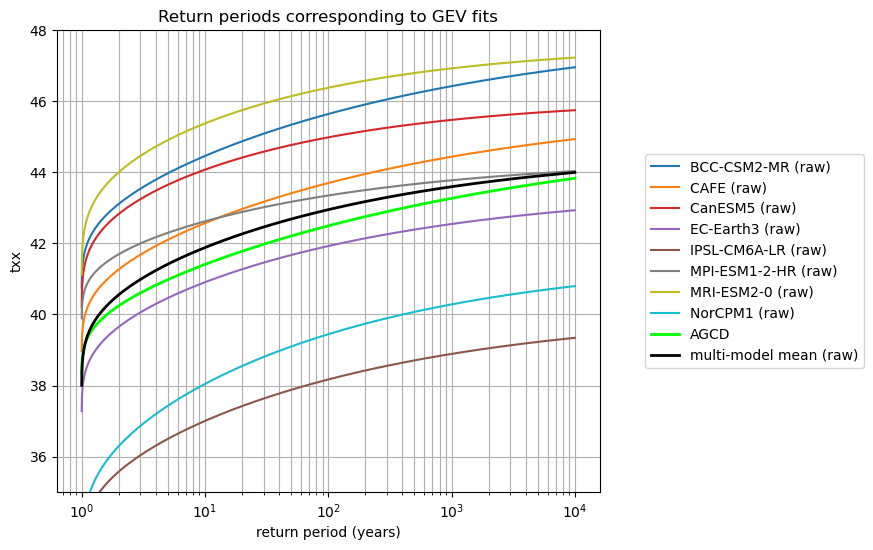

In [14]:
plot_return_curves(
    metric,
    ['model-raw', 'obs'],
    model_dict,
    return_df,
    ylim=[35, 48],
)

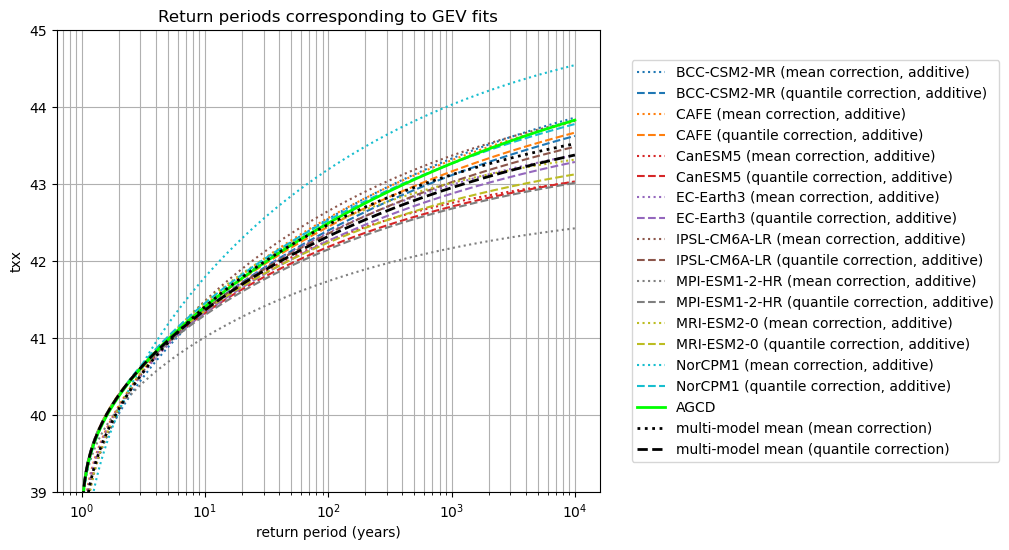

In [15]:
plot_return_curves(
    metric,
    ['model-bc-mean', 'model-bc-quantile', 'obs'],
    model_dict,
    return_df,
    ylim=[39, 45],
    legend_offset=1.75,
)

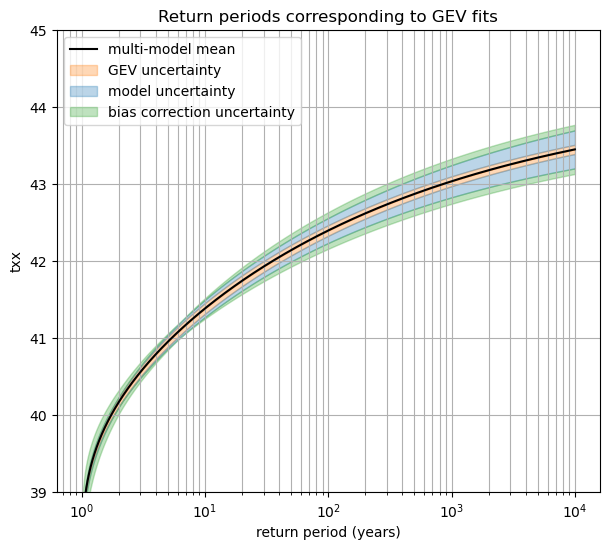

In [16]:
plot_uncertainty(metric, return_df, gev_spread_df, ylim=[39, 45])

## rx1day

In [17]:
metric = 'rx1day'
location = 'Katherine'
model_dict = {
    'BCC-CSM2-MR': 'tab:blue',
#    'CAFE': 'tab:orange',
    'CMCC-CM2-SR5': 'tab:green',
    'CanESM5': 'tab:red',
    'EC-Earth3': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'MIROC6': 'tab:pink',
    'MPI-ESM1-2-HR': 'tab:grey',
    'MRI-ESM2-0': 'tab:olive',
    'NorCPM1': 'tab:cyan',
}  

In [18]:
return_df, gev_spread_df = get_return_values(metric, location, model_dict)

BCC-CSM2-MR


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


CMCC-CM2-SR5
CanESM5


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


EC-Earth3
IPSL-CM6A-LR
MIROC6


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


MPI-ESM1-2-HR
MRI-ESM2-0
NorCPM1


/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values
/jobfs/142455149.gadi-pbs/ipykernel_2942779/2984834905.py:11: RuntimeWarning: invalid value encountered in subtract
  diff = return_values - reference_return_values


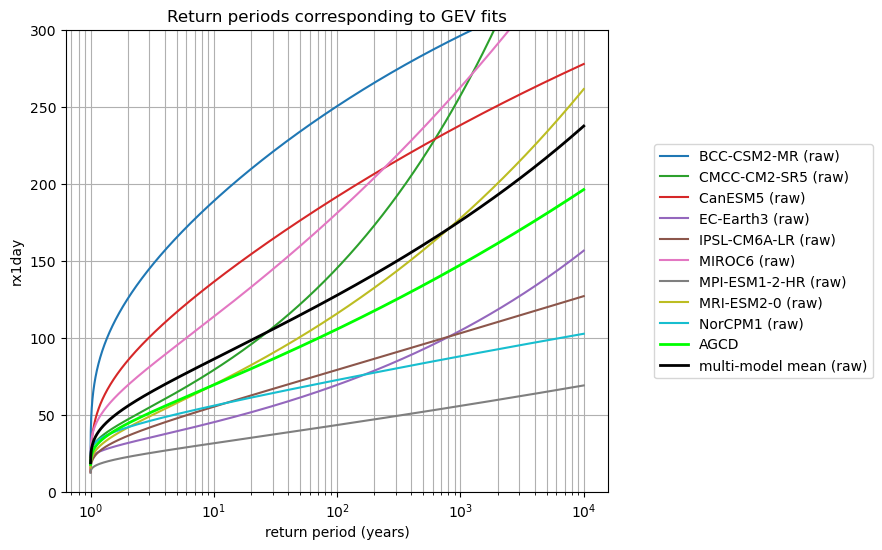

In [19]:
plot_return_curves(
    metric,
    ['model-raw', 'obs'],
    model_dict,
    return_df,
    ylim=[0, 300],
)

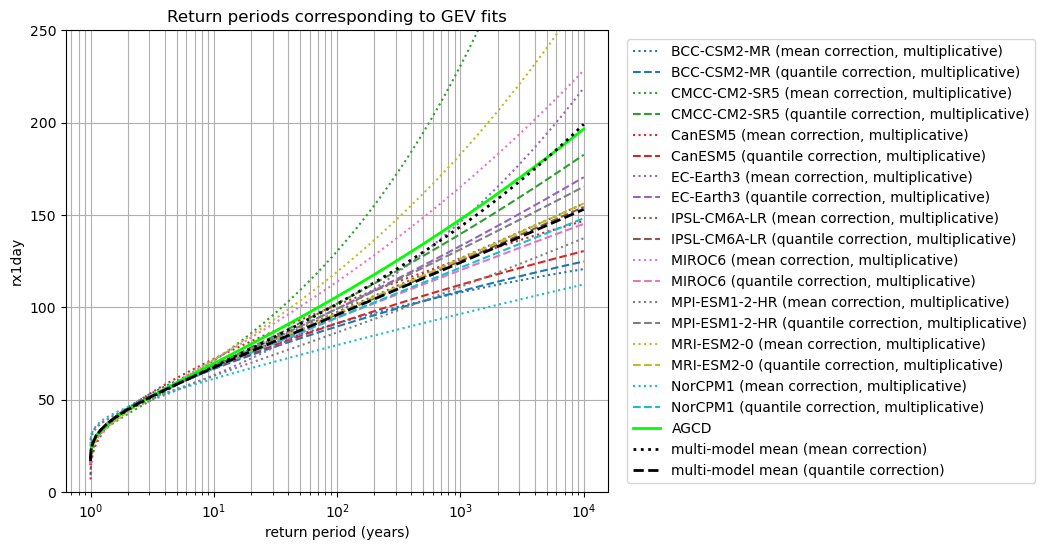

In [20]:
plot_return_curves(
    metric,
    ['model-bc-mean', 'model-bc-quantile', 'obs'],
    model_dict,
    return_df,
    ylim=[0, 250],
    legend_offset=1.8
)

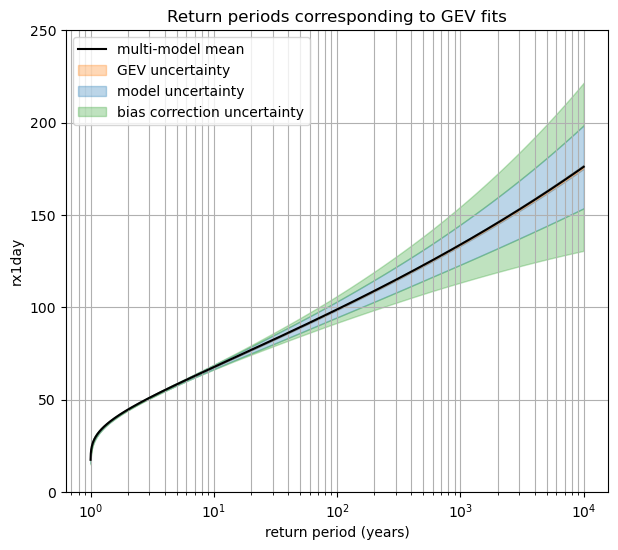

In [21]:
plot_uncertainty(metric, return_df, gev_spread_df, ylim=[0, 250])